# Predicting Heart Disease using Machine Learning

### 1 problem Def
### 2 Data
### 3 Evaluatoin 
### 4 features
### 5 modelling
### 6 experimentation

## problem 
Given Clinical parameters about a patinet , can we predict  whether  or not  have a heart disease

## Data 
This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

Kaggel 
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## Evaluation
>if we can reach 95 acc and predict , we'll pursue the project 


## Features
* age
* sex 1 -> male & 0 -> female
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
* The names and social security numbers of the patients were recently removed
* from the database, replaced with dummy values.

In [90]:
# import the tools 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# import models 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

In [91]:
# load the data
df = pd.read_csv(r"heart-disease.csv")
df.shape

(303, 14)

In [92]:
#explore the data
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [93]:
df["target"].value_counts()#how many classes are there?

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

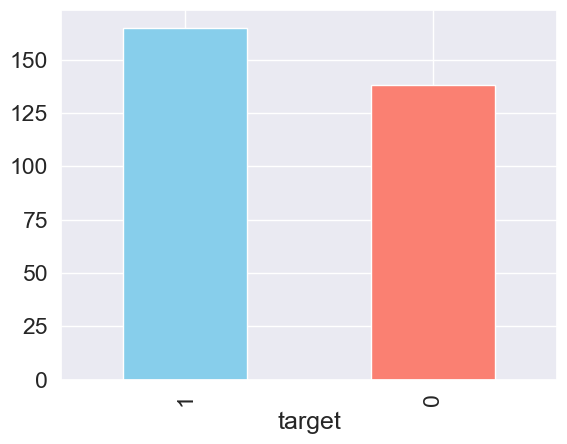

In [94]:
df["target"].value_counts().plot(kind="bar",color=["skyblue","salmon"])


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [96]:
# missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [97]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [98]:
#compare the features to find more patterns


# freq according to sex

df.sex.value_counts()


sex
1    207
0     96
Name: count, dtype: int64

In [99]:
# compare the target with sex
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


In [100]:
# Calculate the percentage of females and males with heart disease
disease_by_sex = pd.crosstab(df.sex, df.target, normalize='index') * 100
print("Percentage of heart disease by sex (0=Female, 1=Male):")
print(disease_by_sex)
print("\nFemales with heart disease:", disease_by_sex.loc[0, 1], "%")
print("Males with heart disease:", disease_by_sex.loc[1, 1], "%")

Percentage of heart disease by sex (0=Female, 1=Male):
target          0          1
sex                         
0       25.000000  75.000000
1       55.072464  44.927536

Females with heart disease: 75.0 %
Males with heart disease: 44.927536231884055 %


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

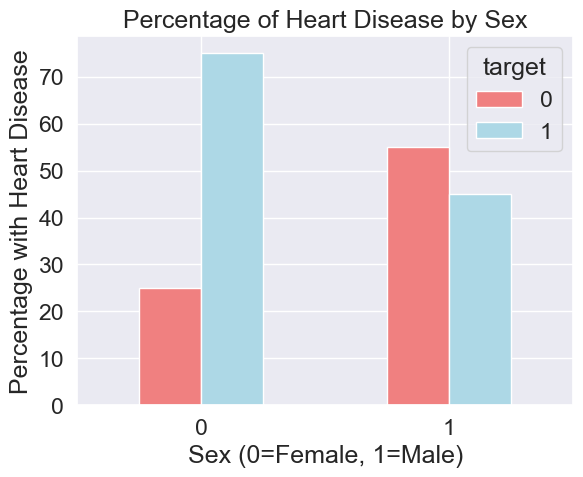

In [101]:
disease_by_sex.plot(kind="bar", color=["lightcoral", "lightblue"])
plt.title("Percentage of Heart Disease by Sex")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.ylabel("Percentage with Heart Disease")
plt.xticks(rotation=0)

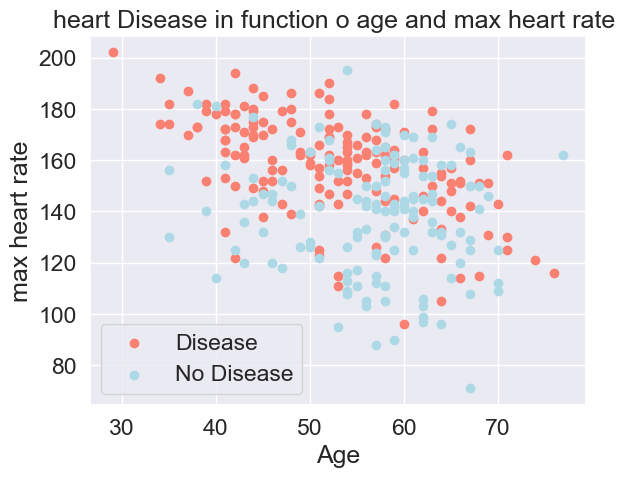

In [102]:
# Scatter with positive examples (target == 1)
# X = age, Y = thalach (max heart rate)
plt.scatter(df.age[df.target==1], 
            df.thalach[df.target==1], 
            c="salmon")

plt.scatter(df.age[df.target==0], 
            df.thalach[df.target==0], 
            c="lightblue")

plt.title("heart Disease in function o age and max heart rate ")
plt.xlabel("Age")
plt.ylabel("max heart rate")
plt.legend(["Disease","No Disease"]);


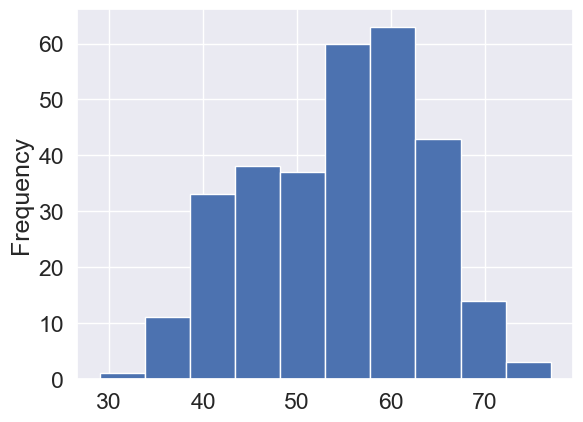

In [103]:
# distribution of the age column with a histogram
df.age.plot.hist();

In [104]:
disease_by_cp=pd.crosstab(df.cp,df.target)

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

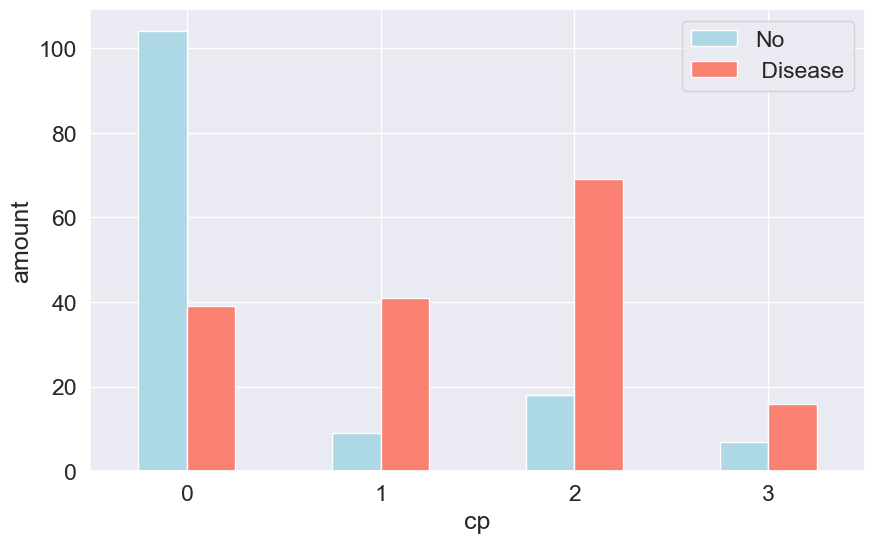

In [105]:
disease_by_cp.plot(kind='bar', figsize=(10,6), color=["lightblue", "salmon"])
plt.xlabel("cp")
plt.ylabel("amount")
plt.legend(["No"," Disease"])
plt.xticks(rotation=0)

In [106]:
# make a corr matrix 
correlation_matrix=df.corr()


In [107]:
correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


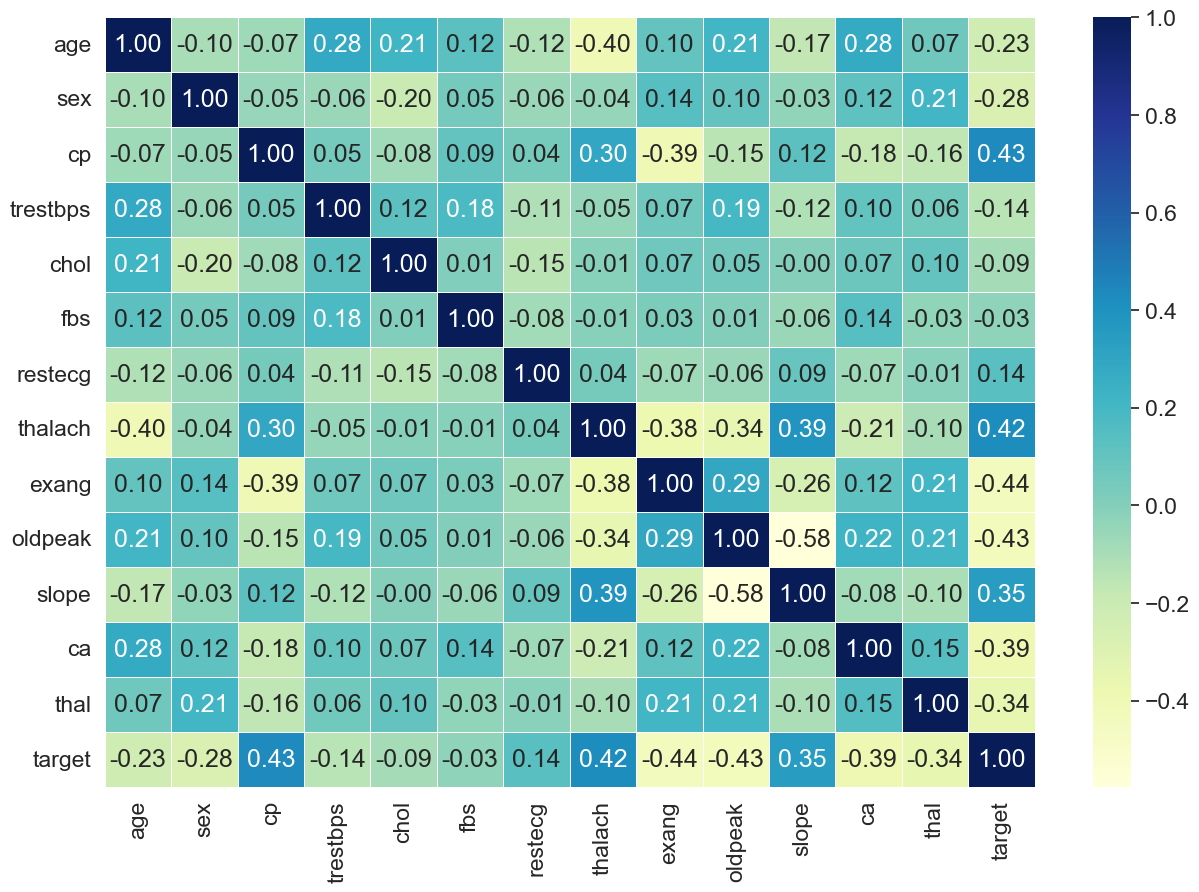

In [108]:
fig , ax=plt.subplots(figsize=(15,10))

ax=sns.heatmap(correlation_matrix,
               annot=True,
               linewidths=0.5,
               fmt=".2f",
                cmap="YlGnBu")

## modelling 


In [109]:
#split data into x and y

x=df.drop("target",axis=1)

y=df["target"]

In [110]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [111]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [112]:
np.random.seed(42)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)



### time to build the model

### we gona to try 3 diff models 

### 1- logistc reg
### 2- KNN
### 3- RF


In [113]:
# put all in dictionary 
models= {"Logistic":LogisticRegression(),
         "RF":RandomForestClassifier(),
         "KNN":KNeighborsClassifier()}

In [114]:
#create a function to fit and score the models

def fit_and_score(models,x_train,x_test,y_train,y_test):
    np.random.seed(42)
    #make a dic to keep scores

    models_scores={}

    # loop through the model

    for name ,model in models.items():
        # fit the data 
        model.fit(x_train,y_train)

        # evaluate each model and append the score 
        models_scores[name]=model.score(x_test,y_test)
        
    return models_scores


In [115]:
model_scores=fit_and_score(models=models,x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)

c:\Users\ii\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [116]:
model_scores

{'Logistic': 0.8852459016393442,
 'RF': 0.8360655737704918,
 'KNN': 0.6885245901639344}

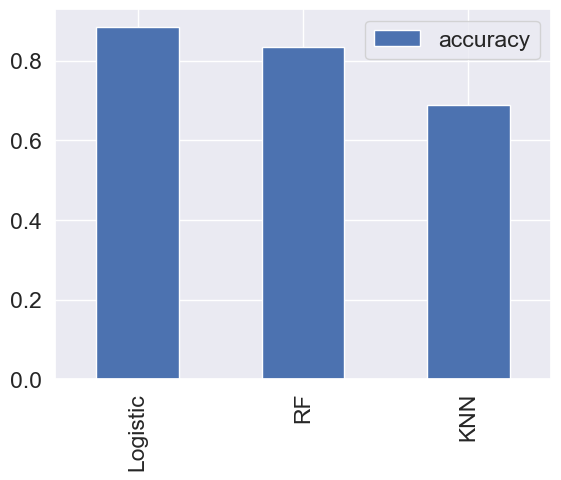

In [117]:
#model comparsion 

model_compare=pd.DataFrame(model_scores,index=["accuracy"])
model_compare.T.plot.bar();

### Now we have the Baseline model 

lets look at the following 
* hyperparameter tuning 
* Feature Imporatnce 
* Confusion Matirx 
* Cross-validation
* pricision
* recall 
* f1 score 
* roc
* aoc



### Hyperparameter tunning 

In [118]:
# lets tune the KNN

train_socres=[]
test_scores=[]

#create a list of diff values for n_neighbors

neigh=range(1,21)

# setup knn instance

knn=KNeighborsClassifier()

# loop through diff n's

for i in neigh:
    knn.set_params(n_neighbors=i)

    #fit the algo 
    knn.fit(x_train,y_train)

    #update the training scores list

    train_socres.append(knn.score(x_train,y_train))

    #update the test scores list 

    test_scores.append(knn.score(x_test,y_test))



In [119]:
train_socres

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [120]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Max Knn score on test data :75.41%


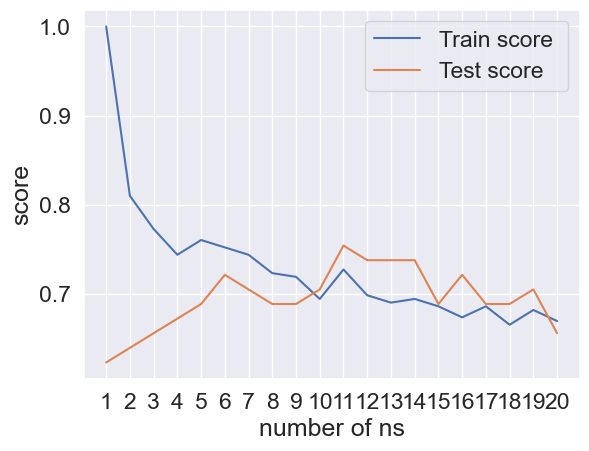

In [121]:
plt.plot(neigh,train_socres,label="Train score ")
plt.plot(neigh,test_scores, label="Test score ")
plt.xticks(np.arange(1,21,1))
plt.xlabel("number of ns")
plt.ylabel("score")
plt.legend()
print(f"Max Knn score on test data :{max(test_scores)*100:.2f}%")

knn didn't work that good

### tunning the logistc & randomforest  using RandomziedSearchCV


In [122]:
#create a hyperparameter grid for logistc 
log_reg_grid={"C":np.logspace(-4,4,20),
              "solver":["liblinear"]}

#create a hyperparameter grid for RF 
rf_reg_grid={"n_estimators":np.arange(10, 1000,50) #number of trees
              ,
             "max_depth":[None,3,5,10]
             ,
             "min_samples_split":np.arange(2,20,2)#min number of patient for go to new leaf
             ,
             "min_samples_leaf":np.arange(1,20,2)# min number of patients for last leaf 
             }


In [123]:
#Tuin the logistc reg
np.random.seed(42)
#setup random hyperparameters search for logistic
#Random expermentation fast result (can once skip best choice)
rs_log=RandomizedSearchCV(LogisticRegression(),
                          param_distributions=log_reg_grid,
                          cv=5,
                          n_iter=20,
                          verbose=True
                          )

#fit random hypermarmeter
rs_log.fit(x_train,y_train)
rs_log.score(x_test,y_test)*100

Fitting 5 folds for each of 20 candidates, totalling 100 fits


88.52459016393442

In [124]:
#now the rf 
np.random.seed(42)

rs_rf=RandomizedSearchCV(RandomForestClassifier(),
                      param_distributions=rf_reg_grid,
                      cv=5,
                      n_iter=20,
                      verbose=True)

In [125]:
rs_rf.fit(x_train,y_train)
rs_rf.score(x_test,y_test)*100

Fitting 5 folds for each of 20 candidates, totalling 100 fits


86.88524590163934

In [126]:
#find the best hyper
rs_log.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [127]:
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [128]:
model_scores #compare to the base 

{'Logistic': 0.8852459016393442,
 'RF': 0.8360655737704918,
 'KNN': 0.6885245901639344}

# hyperparameter tunnig with GridSearchCV


In [129]:
log_reg_grid={"C":np.logspace(-4,4,30),
              "solver":["liblinear"]
              }

rf_reg_grid={"n_estimators":np.arange(100,1000,50),
             "max_depth":[None,3,5,10],
             "min_samples_split":np.arange(2,20,2),
             "min_samples_leaf":np.arange(1,20,2)}

In [130]:
# try each parameter to achive best approch (might be slow )
gs_log_reg=GridSearchCV(LogisticRegression(),
                        param_grid=log_reg_grid,
                        cv=5,
                        verbose=True)
gs_log_reg.fit(x_train,y_train)
gs_log_reg.score(x_test,y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


0.8852459016393442

In [131]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [132]:
model_scores

{'Logistic': 0.8852459016393442,
 'RF': 0.8360655737704918,
 'KNN': 0.6885245901639344}

###  Evaluting our tuned machine learnig classifier ,beyond accuracy 

lets look at the following 
* Confusion Matirx 
* Cross-validation
* pricision
* recall 
* f1 score 
* roc
* aoc



In [133]:
# make predictions with tuend model
y_preds=gs_log_reg.predict(x_test)

y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [134]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

ROC is the like a guard that has a thershold control which was 20% he will arrest alot of non crminals 
otherwise if his do his job 100% he will never arrest civilians non crimnals 
so roc is try to control the thershold to achive best predict 


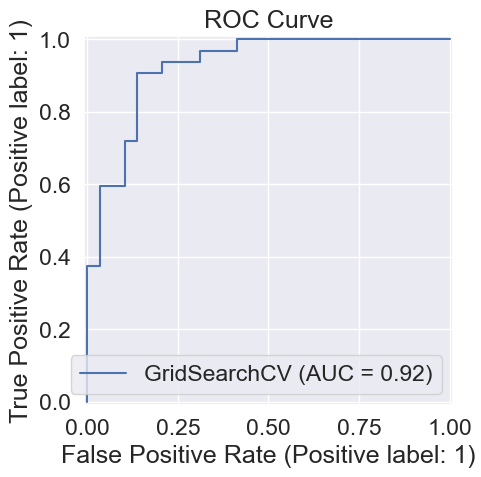

AUC: 0.9246


In [135]:
#plot ROC and calculate it and AOC 
roc_display = RocCurveDisplay.from_estimator(gs_log_reg, x_test, y_test)
plt.title("ROC Curve")
plt.show()

print(f"AUC: {roc_display.roc_auc:.4f}")

Aoc is the range in 0 & 1 which nearest num to the 1 means that the prdiction is good 

 The Logistic Regression model demonstrates excellent performance, 
 achieving an ROC AUC score of 0.92. This indicates a 92% probability 
 that the model correctly distinguishes between a patient with heart disease 
 and a healthy individual.

## Confusion matrix 

In [136]:
print(confusion_matrix(y_test,y_preds))#compare real with our preds

[[25  4]
 [ 3 29]]


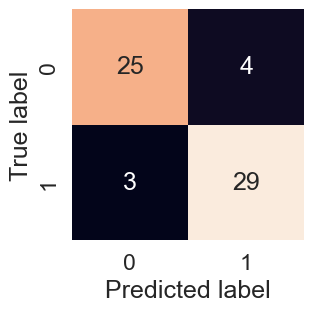

In [137]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True# to write numbers inside the squares 
                     ,
                     cbar=False)
                     
    plt.xlabel("Predicted label") 
    plt.ylabel("True label")

plot_conf_mat(y_test=y_test, y_preds=y_preds)

In [138]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### calc report use corss validation (5-fold)

In [139]:
# check the best hyperparameters to  apply the crossvalidation on it 
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

In [145]:
#create a new classifier with best parameters
clf= LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")

In [146]:
#cross-val accuracy
cv_acc=cross_val_score(clf,
                       x,
                       y,
                       cv=5,
                       scoring="accuracy")
cv_acc_mean=np.mean(cv_acc)
cv_acc_mean


np.float64(0.8479781420765027)

In [147]:
#cross-val precision
cv_prec=cross_val_score(clf,
                       x,
                       y,
                       cv=5,
                       scoring="precision")
cv_prec
cv_prec_mean=np.mean(cv_prec)
cv_prec_mean

np.float64(0.8215873015873015)

In [150]:
#cross-recall
 
cv_recall=cross_val_score(clf,
                       x,
                       y,
                       cv=5,
                      scoring="recall")
cv_recall
cv_recall_mean=np.mean(cv_recall)
cv_recall_mean

np.float64(0.9272727272727274)

In [149]:
#cross-val f1
#cross-recall
 
cv_f1=cross_val_score(clf,
                       x,
                       y,
                       cv=5,
                       scoring="f1")
cv_f1
cv_f1_mean=np.mean(cv_f1)
cv_f1_mean

np.float64(0.8705403543192143)

<Axes: title={'center': 'Cross-validated classification '}>

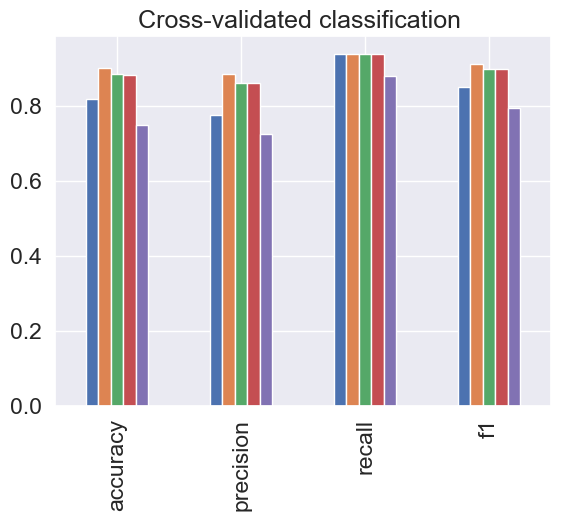

In [152]:
#visualize cross-validated met
cv_met=pd.DataFrame({"accuracy":cv_acc,
                     "precision":cv_prec,
                     "recall":cv_recall,
                     "f1":cv_f1})
cv_met.T.plot.bar(title="Cross-validated classification ",
                 legend=False )

### Feature Importance 

is another way of askin which features contributed most to the outcomes of the model?   it diff between model to another 

Target distribution by sex:


target,0,1
sex,,
0,24,72
1,114,93



Target distribution by slope:


target,0,1
slope,,
0,12,9
1,91,49
2,35,107


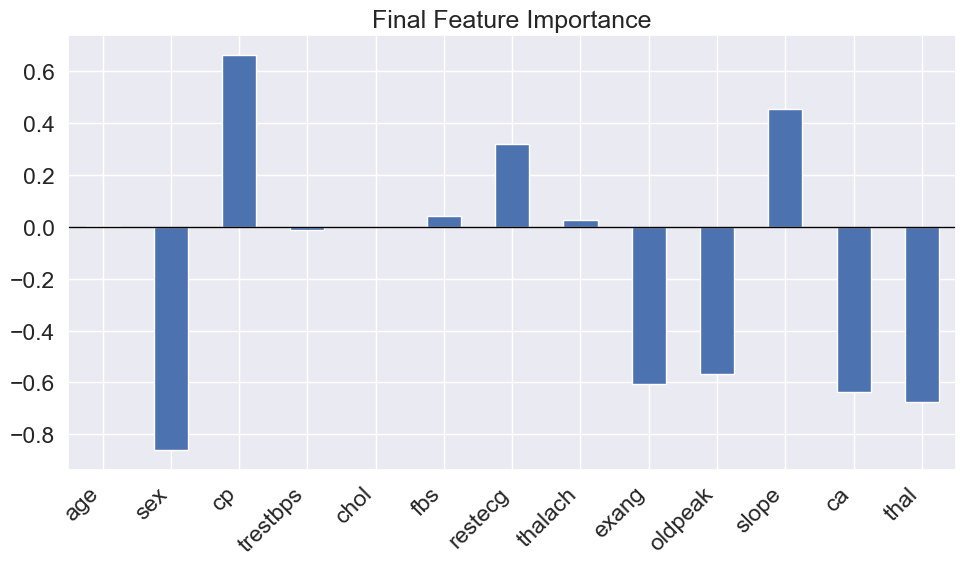

In [153]:
# Feature Importance (Logistic Regression)
# Coefficients show how each feature contributes to predicting class 1 (heart disease).

# Use the best hyperparameters found earlier by GridSearchCV.
best_params = gs_log_reg.best_params_
clf = LogisticRegression(
    C=best_params["C"],
    solver=best_params["solver"],
    random_state=42
)

# Fit the model on the training data.
clf.fit(x_train, y_train)

# Map each feature name to its learned coefficient.
feature_dict = dict(zip(x_train.columns, clf.coef_[0]))
feature_df = pd.DataFrame(feature_dict, index=[0])

# Show feature importance sorted by absolute magnitude.
feature_df.T.sort_values(by=0, key=lambda s: s.abs(), ascending=False)

# Visualize feature importance.
# Positive value: pushes prediction toward heart disease (target=1)
# Negative value: pushes prediction toward no heart disease (target=0)
feature_df.T.plot(
    kind="bar",
    figsize=(10, 6),
    title="Final Feature Importance",
    legend=False
)
plt.axhline(y=0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout();

# Quick model-driven EDA checks (as discussed):
disease_by_sex = pd.crosstab(df["sex"], df["target"])
disease_by_slope = pd.crosstab(df["slope"], df["target"])

print("Target distribution by sex:")
display(disease_by_sex)
print("\nTarget distribution by slope:")
display(disease_by_slope)